# Лекция 8. Моделирование дискретных событий. Аппроксимация немарковских процессов.

1. Моделирование дискретных событий (DES) с использованием библиотеки Simmer в R
2. Аппроксимация немарковских процессов

## Моделирование дискретных событий (DES) с использованием библиотеки Simmer в R

Во многих реальных случаях аналитические модели оказываются недоступны, тогда используют методы иммитационного моделирования.

В зависимости от характера рассматриваемой системы применяются различные типы моделирования. Их можно классифицировать по таким основным направлениям:
- детерминистический или стохастический;
- статический или динамический (в зависимости от того, меняются ли параметры системы во времени) 
- непрерывного или дискретного (в зависимости от того, как меняется система). 

Например, методы Монте-Карло являются хорошо известными примерами методов статического стохастического моделирования. 
С другой стороны, моделирование дискретных событий (discrete event simulation - DES) это особый метод моделирования стохастических, динамических и дискретно развивающихся систем. В отличие от непрерывного моделирования, в котором обычно используются плавно развивающиеся эквациональные модели, DES характеризуется внезапными изменениями состояния в точные моменты (моделированного) времени.

Системы дискретно-событийного моделирования — это, чаще всего, проблемно-ориентированные языки программирования или библиотеки для высокоуровневых языков. Наиболее известные: Arena, AnyLogic, GPSS, SimPy.

Подобные библиотеки начинают возникать и для других языков программирования. Для R подобная библиотека получила название **[Simmer](https://r-simmer.org/)**. Прямыми конкурентами simmer являются SimPy (Team SimPy 2017) и SimJulia (Lauwens 2017), созданные для языков Python и Julia соответственно.

Разработка пакета Simmer началась во второй половине 2014 года. Фреймворк DES для R возник в проектах, связанных с оптимизацией процессов в здравоохранении. В большинстве этих случаев пациенты следовали четкой траектории прохождения лечения. Это постепенно привело к принятию и внедрению концепции траектории, лежащей в основе движка DES Simmer. Этот подход стал в некоторой степени новаторским и, что немаловажно, очень интуитивным.

Ядро любого современного симулятора дискретных событий состоит из двух основных компонентов: списка событий, упорядоченного по времени возникновения, и цикла событий, который извлекает и выполняет события. В отличие от других интерпретируемых языков, таких как Python, который по умолчанию компилируется в промежуточный байт-код, код R анализируется и оценивается исключительно во время выполнения. Этот факт делает язык R особенно медленным для DES, который состоит из выполнения сложных процедур (кусков кода, связанного с событиями) внутри цикла при постоянном выделении и освобождении объектов (в очереди событий). По этой причине основное ядро моделирования написано на C++. Для интерфейса R API с этим ядром C++ используя пакет Rcpp, который стал одним из самых популярных способов расширения пакетов R с помощью кода C или C++.

В DES есть определенная терминология, например, событие, система, состояние, сущность или атрибут.:
 - **Событие** – это дискретное изменение состояния системы, которое происходит в определенный момент времени. События могут быть инициированы внешними факторами или внутренними процессами системы.
 - **Система** -  это объект, который моделируется с помощью DES. Система может быть физическим объектом, таким как производственная линия, или абстрактным объектом, таким как компьютерная сеть.
 - **Состояние** - это комбинация значений переменных, которые определяют текущее состояние системы. Состояние системы может изменяться в результате событий.
 - **Сущность** - это объект интереса в системе (например, пациент).
 - **Атрибут** - это свойство сущности.
 
Однако существуют некоторые термины, специфичные для Simmer, и некоторые элементы.
которые требуют дальнейшего объяснения для понимания архитектуры пакета.

**Ресурс**  - пассивная сущность, как ее обычно понимают в стандартной терминологии DES.
Однако ресурсы Simmer задуманы с учетом систем массового обслуживания, и поэтому
они состоят из двух внутренних самоуправляемых частей: сервер, который концептуально представляет сам ресурс, имеет определенную емкость и его можно захватить и отпустить; очередь  - приоритетная очередь определенного размера.

**Менеджер** -  активный объект, т. е. процесс, который имеет возможность корректировать свойства объекта-ресурса (емкость и размер очереди) во время выполнения.

**Источник** -  процесс, ответственный за создание новых поступлений с заданным временным интервалом между поступлениями и вставку их в имитационную модель.

**Прибытие** - процесс, способный взаимодействовать с ресурсами или другими объектами моделирования.
С ним могут быть связаны некоторые атрибуты и значения приоритетов, и, как правило,
ограниченный срок жизни. При создании каждое прибытие привязывается к заданной траектории.

**Траектория** -  взаимосвязь действий, составляющих рецепт достижения, связанный с ней, т.е.
упорядоченный набор действий, которые необходимо выполнить. Имитационная модель в конечном итоге
представлена набором траекторий.

**Деятельность (активность)** -  индивидуальная единица действия, которая позволяет прибывшим взаимодействовать с ресурсами и другими сущностями, выполнять собственные процедуры, проводя время в системе, возвращаясь назад динамично двигаться вперед по траектории и многое другое.

Прежде чем начать работать с DES в R необходимо установить требуемые библиотеки:

In [ ]:
#Основная библиотека Simmer
install.packages("simmer")

#Библиотека для удобной визуализации результатов
install.packages("simmer.plot")

#Библиотека для визуализации траектории
install.packages("brewer_pal")

In [1]:
#Подключаем данные библиотеки
library(simmer)
library(simmer.plot)

Загрузка требуемого пакета: ggplot2


Присоединяю пакет: ‘simmer.plot’


Следующие объекты скрыты от ‘package:simmer’:

    get_mon_arrivals, get_mon_attributes, get_mon_resources




Рассмотрим простейшую систему $M/M/1/\infty$ с интенсивностями входящего потока и потока обслуживания $\lambda=0.8, \mu=1.3$ соответственно. Для моделирования прежде всего необходимо создать траекторию движения заявок - здесь все предельно просто: заявка поступает на канал, захватывает его на случайное время $\frac{1}{\mu}$, и освобождает его:

In [2]:
#Создание траектории системы M/M/1/inf
lambda <- 0.8
mu <- 1.3

my.trajectory <- trajectory() %>%
  seize("server", amount=1) %>%
  timeout(function() rexp(1, mu)) %>%
  release("server", amount=1)

В приведенном коде используются следующие функции:
- **seize** - захватывает заданное количество указанных ресурсов.
- **timeout** - осуществляет задержку дальнейшего движения сущности по траектории. В данном случае аргументом действия timeout является функция, которая вычисляется динамически для получения стохастического времени ожидания, но она также может быть константой. Кроме того, эта функция может быть настолько сложной, насколько вам нужно, и делать все, что вы захотите: взаимодействовать с сущностями вашей имитационной модели, получать статус ресурсов, принимать решения в соответствии с последним.
- **release** - освобождает заданное количество указанных ресурсов.

Траекторию можно определить как рецепт, и она состоит из упорядоченного набора действий. Метод trajectory() создает экземпляр объекта, и действия можно добавлять с помощью метода %>%.

Сам по себе потоковый оператор %>% служит перенаправлению ввода вывода:

In [3]:
7 %>% log() %>% sin()
sin(log(7))

[1] 0.9304659

[1] 0.9304659

Рассмотрим некоторые примеры работы с траекториями.

In [4]:
traj0 <- trajectory() %>%
log_("Entering the trajectory") %>%
timeout(10) %>%
log_("Leaving the trajectory")

Здесь с помощью функции **log_()** выводится сообщение о соответствующем действии в процессе моделирования.  Заявка, связанная с этой траекторией выполнит действия в заданном порядке, т. е. отобразит «Вход в траекторию» ("Entering the trajectory"), затем  потратится 10 единиц модельного времени и, наконец, отобразится «Уход из траектории» ("Leaving the trajectory").

В примере используются фиксированные параметры: строка и числовое значение соответственно. Однако можно указывать то, что мы будем называть динамическим параметром, то есть функцией. Таким образом, хотя и не совсем полезно тем не менее, также справедливо:

In [5]:
traj1 <- trajectory() %>%
log_(function() "Entering the trajectory") %>%
timeout(function() 10) %>%
log_(function() "Leaving the trajectory")

По траектории можно ходить индексами:

In [6]:
#Это вся траектория
traj0

trajectory: anonymous, 3 activities
{ Activity: Log          | message: Entering t..., level: 0 }
{ Activity: Timeout      | delay: 10 }
{ Activity: Log          | message: Leaving th..., level: 0 }

In [7]:
#Это ее первая часть
traj0[0]

trajectory: anonymous, 0 activities

In [8]:
# Это вторая часть и т.д.
traj0[1]

trajectory: anonymous, 1 activities
{ Activity: Log          | message: Entering t..., level: 0 }

Соответственно, траектории можно разделить, объединить и изменить:

In [9]:
traj2 <- join(traj0[c(1, 3)], traj0[2])
traj2[1] <- traj2[3]
traj2

trajectory: anonymous, 3 activities
{ Activity: Timeout      | delay: 10 }
{ Activity: Log          | message: Leaving th..., level: 0 }
{ Activity: Timeout      | delay: 10 }

Траекторию можно визуализировать.

In [10]:
get_palette <- scales::brewer_pal(type = "qual", palette = 1)
plot(my.trajectory, fill = get_palette)

HTML widgets cannot be represented in plain text (need html)

In [11]:
plot(traj2, fill = get_palette)

HTML widgets cannot be represented in plain text (need html)

После определения траектории можно переходить непосредственно к моделированию:

In [12]:
Tmodel<-200000
mm_1_inf <- simmer() %>%
  add_resource("server", capacity=1, queue_size=Inf) %>%
  add_generator("arrival", my.trajectory, function() rexp(1, lambda)) %>%
  run(until=Tmodel)

Рассмотрим использованные функции
- **simmer()** - данный метод инициализирует рабочее окружение модели
- **[add_resource()](https://r-simmer.org/reference/add_resource.html?q=add_resource#null)** - определяет новый ресурс в среде моделирования
- **[add_generator()](https://r-simmer.org/reference/add_generator.html?q=add_generator#null)** - присоединяет к траектории новый источник поступления заявок
- **run()** - выполняет шаги до достижения заданного значения

В принципе моделирование закончено, переменная - объект mm_1_inf хранит все необходимые результаты.

Для того, чтобы посмотреть статистику по заявкам, нужно использовать метод **[get_mon_arrivals](https://r-simmer.org/reference/get_mon.html?q=get_mon_arrivals#ref-usage)**. Данная функция возвращает датафрейм со временем прихода в систему, ухода заявки из системы, временем обслуживания, а также признаком успешного обслуживания (finished = TRUE).

Функция имеет следующие параметры:

get_mon_arrivals(.envs, per_resource = FALSE, ...)

 per_resource - если TRUE, статистика будет сообщаться по каждому ресурсу.

In [20]:
res_arrivals <- get_mon_arrivals(mm_1_inf)
View(res_arrivals)

name,start_time,end_time,activity_time,finished,replication
<chr>,<dbl>,<dbl>,<dbl>,<lgl>,<int>
arrival0,0.1145165,0.9096323,0.79511576,TRUE,1
arrival1,1.0461845,1.2124789,0.16629438,TRUE,1
arrival2,1.7845622,2.0931835,0.30862134,TRUE,1
arrival3,2.5188140,2.5747925,0.05597853,TRUE,1
arrival4,4.7586211,5.0146250,0.25600396,TRUE,1
arrival5,5.7827510,6.0821490,0.29939800,TRUE,1
arrival6,6.0736008,6.3834299,0.30128090,TRUE,1
arrival7,7.4789484,7.5797114,0.10076297,TRUE,1
arrival8,7.6111248,7.7262674,0.11514268,TRUE,1


По этой таблице легко посчитать среднее время нахождения заявки в системе $T_{\text{сист}}$:

In [21]:
cat("Tsys =", mean(res_arrivals$end_time - res_arrivals$start_time))

Tsys = 2.001988

Можно также посчитать среднее время в очереди $W_{\text{оч}}$:

In [22]:
cat("Woch =", mean(res_arrivals$end_time - res_arrivals$start_time-res_arrivals$activity_time))

Woch = 1.232315

Выполним расчет соответствующих теоретических значений:

$$y=\frac{\lambda}{\mu}\approx 0.615, L_{\text{сист}} = \frac{y}{1-y}=1.6$$
$$T_{\text{сист}} = \frac{L_{\text{сист}}}{\lambda}=2$$
$$W_{\text{оч}}=\frac{y^2}{\lambda(1-y)}\approx 1.23$$
$$L_{\text{оч}} = \frac{y^2}{(1-y)}\approx 0.985$$

In [26]:
y<-lambda/mu; cat("y =",y);
Lsys<-y/(1-y);cat(" Lsys =", Lsys);
Tsys<-Lsys/lambda;cat(" Tsys =", Tsys);
Woch<-y^2/(lambda*(1-y)); cat(" Woch =", Woch);
Loch<-y^2/(1-y); cat(" Loch =",Loch);

y = 0.6153846 Lsys = 1.6 Tsys = 2 Woch = 1.230769 Loch = 0.9846154

Кроме статистики по заявкам, можно смотреть статистику по ресурсам. Это возможно с помощью функции **[get_mon_resources](https://r-simmer.org/reference/get_mon)**:

In [24]:
res_resource<-get_mon_resources(mm_1_inf)
View(res_resource)

resource,time,server,queue,capacity,queue_size,system,limit,replication
<chr>,<dbl>,<int>,<int>,<dbl>,<dbl>,<int>,<dbl>,<int>
server,0.1145165,1,0,1,Inf,1,Inf,1
server,0.9096323,0,0,1,Inf,0,Inf,1
server,1.0461845,1,0,1,Inf,1,Inf,1
server,1.2124789,0,0,1,Inf,0,Inf,1
server,1.7845622,1,0,1,Inf,1,Inf,1
server,2.0931835,0,0,1,Inf,0,Inf,1
server,2.5188140,1,0,1,Inf,1,Inf,1
server,2.5747925,0,0,1,Inf,0,Inf,1
server,4.7586211,1,0,1,Inf,1,Inf,1


По этой таблице можно рассчитать количество заявок в системе и количество заявок в очереди (можно, конечно, использовать формулу Литтла). Однако сложность в том, что для правильного расчета эти количества нужно соотносить через равные промежутки времени, а в нашей таблице фиксируются любые события, связанные с изменением сервера: приход заявки, уход заявки после обслуживания. Поэтому необходимо выполнить дополнительный цикл, в котором выбираются количества заявок из очереди или из системы через равные промежутки времени. 

In [37]:
#Расчет количества заявок в очереди
LL<-c()
t<-0
h<-100
while(t<Tmodel)
  { query<-res_resource$queue[(res_resource$time > t)& (res_resource$time < t+1)][1]
    if (is.na(query)) query<-0 
    LL<-c(LL, query);t<-t+h}
sum(LL)/(Tmodel/h)

[1] 0.9215

In [35]:
#Расчет количества заявок в системе
LL<-c()
t<-0
h<-100
while(t<Tmodel)
  { query<-res_resource$system[(res_resource$time > t)& (res_resource$time < t+1)][1]
    if (is.na(query)) query<-0 
    LL<-c(LL, query);t<-t+h}
sum(LL)/(Tmodel/h)

[1] 1.5415

В тоже время существуют и более удобные средства визуализации результатов моделирования с использованием библиотеки **simmer.plot**.

Для каждой функции мониторинга заявок и ресурсов имеются свои метрики.

Для get_mon_resources первой такой метрикой является использование ресурсов:
 - "utilization"  - среднее время использования ресурса за общее временя моделирования

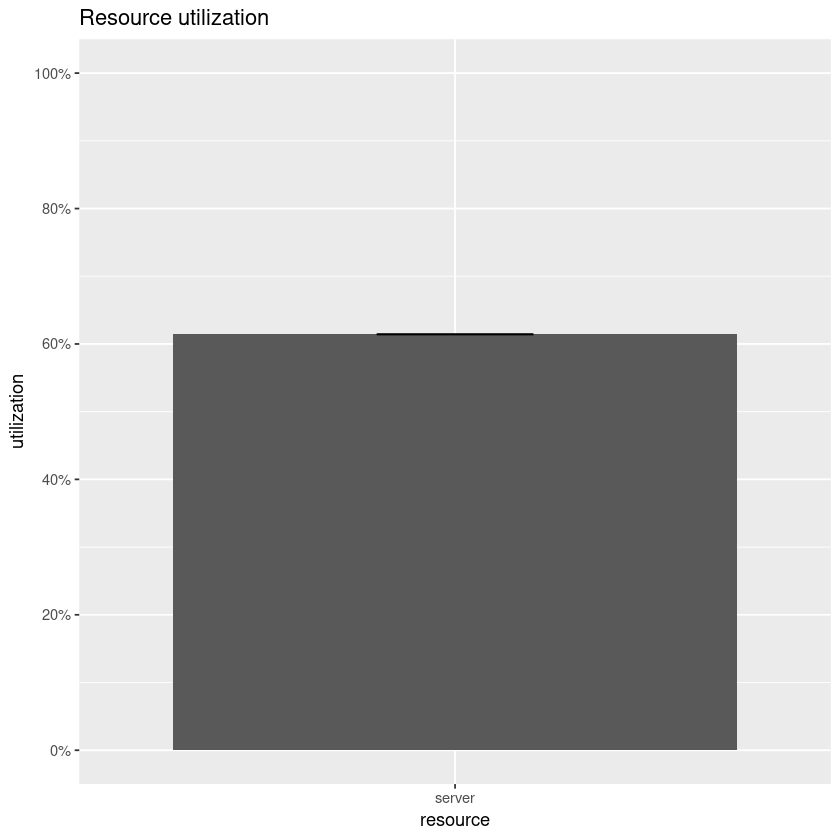

In [41]:
plot(get_mon_resources(mm_1_inf), "utilization", "server")

Здесь мы видим, что сервер используется на уровне 60%.

Следующей метрикой для get_mon_resources является:
- "usage" - позволяет определить, как много различных составляющих ресурса используется по отношению ко времени.

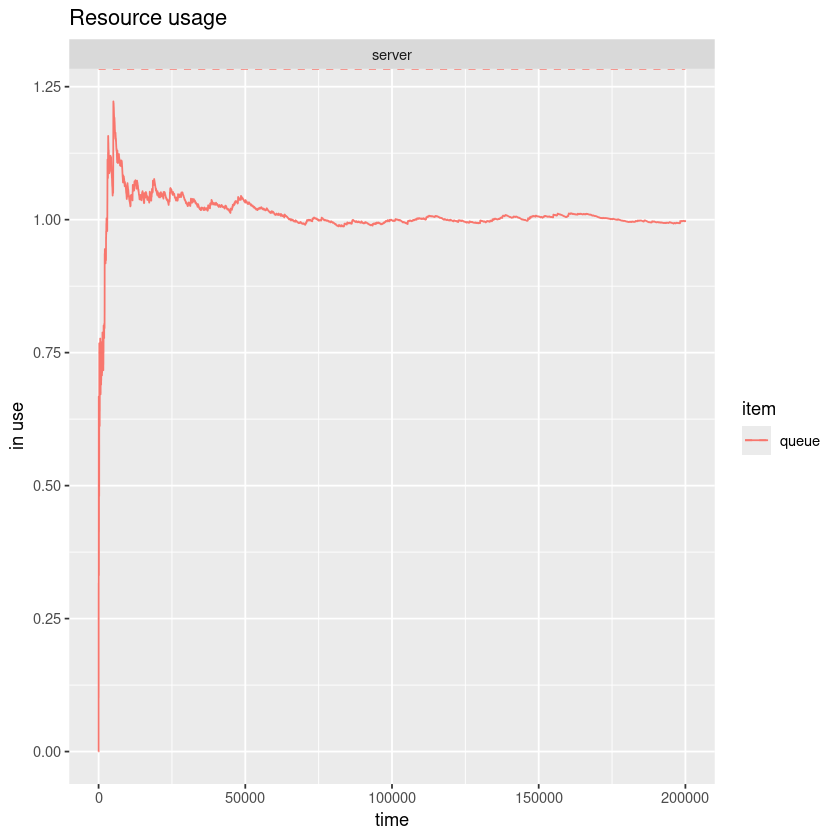

In [30]:
#Находим среднюю длину очереди
plot(get_mon_resources(mm_1_inf), "usage", "server", items="queue")

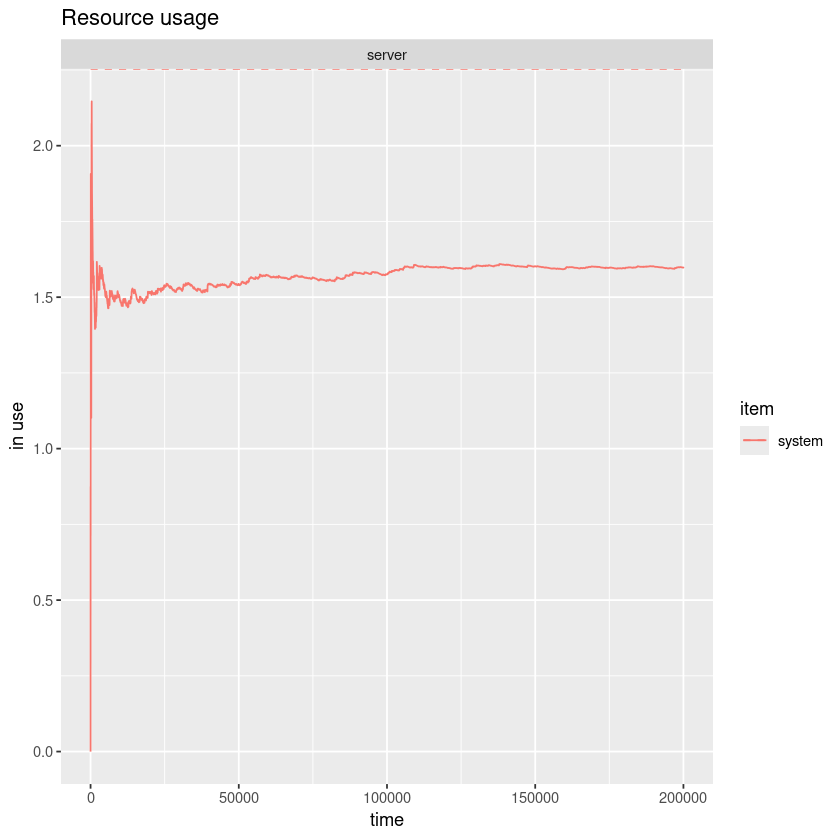

In [42]:
#Находим среднее число заявок в системе
plot(get_mon_resources(mm_1_inf), "usage", "server", items="system")

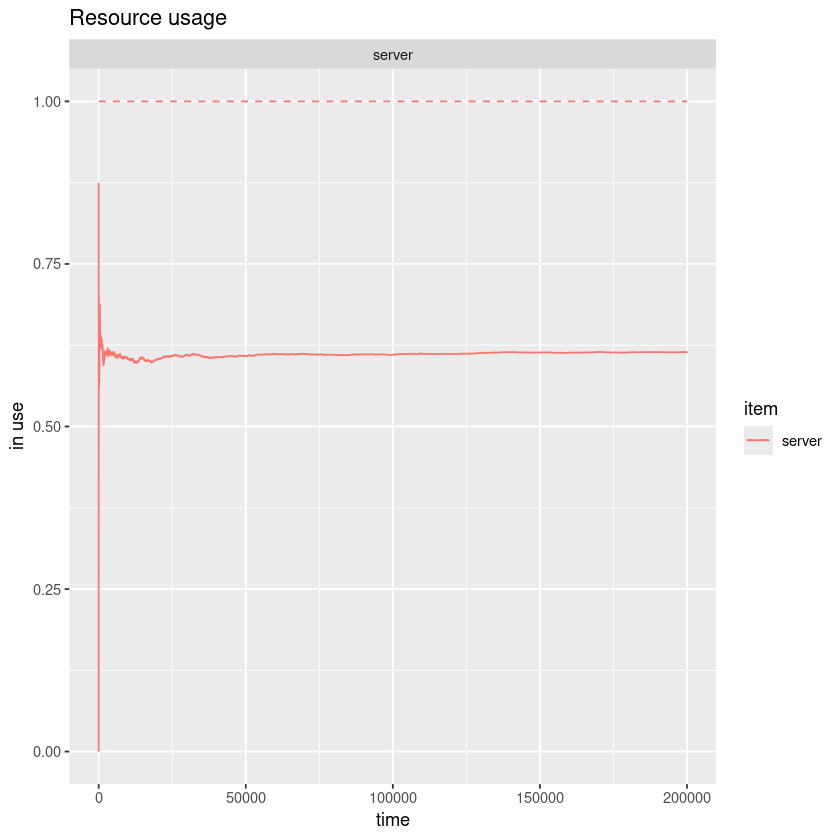

In [43]:
#Находим туже самую долю использования сервера
plot(get_mon_resources(mm_1_inf), "usage", "server", items="server")

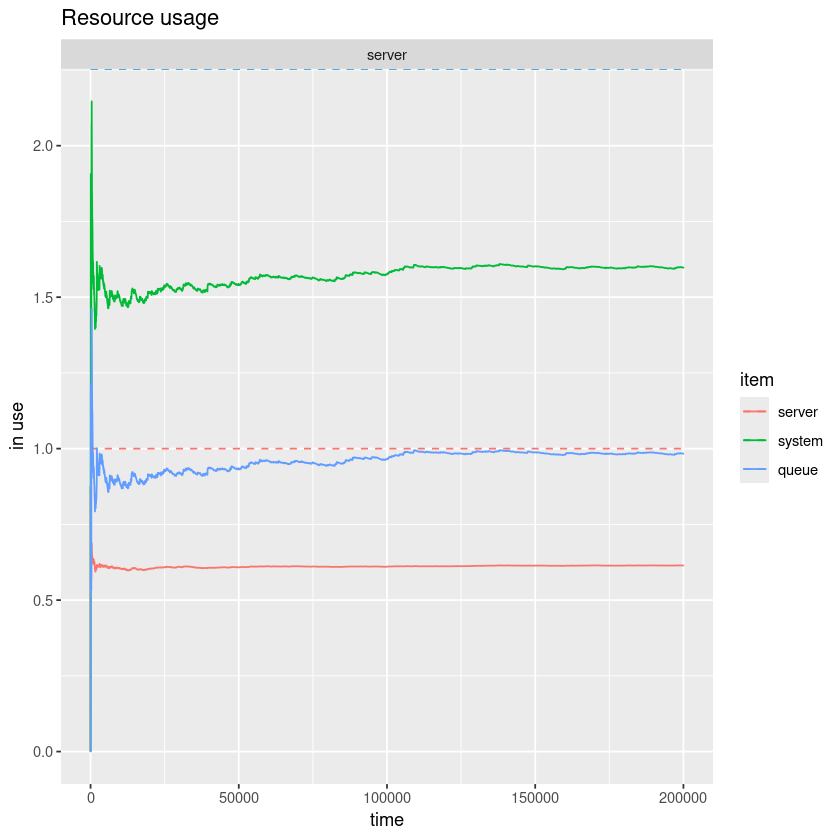

In [45]:
#Все это можно совместить на одной картинке
plot(get_mon_resources(mm_1_inf), "usage", "server", items=c("server", "system", "queue"))

Для функции мониторинга заявок get_mon_arrivals имеются следующие метрики:
- activity_time = время выполнения
- flow_time = общее время, проведенное в системе
- waiting_time = время между действиями, flow_time - activity_time

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'
`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


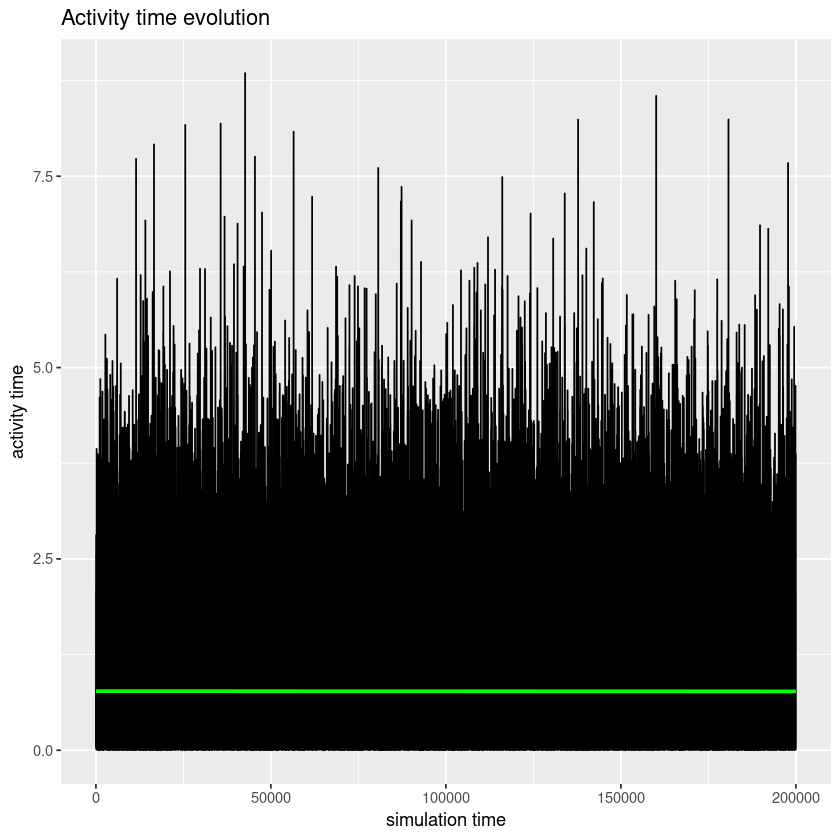

In [47]:
plot(res_arrivals, metric = "activity_time") + geom_smooth (color= "green")

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'
`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


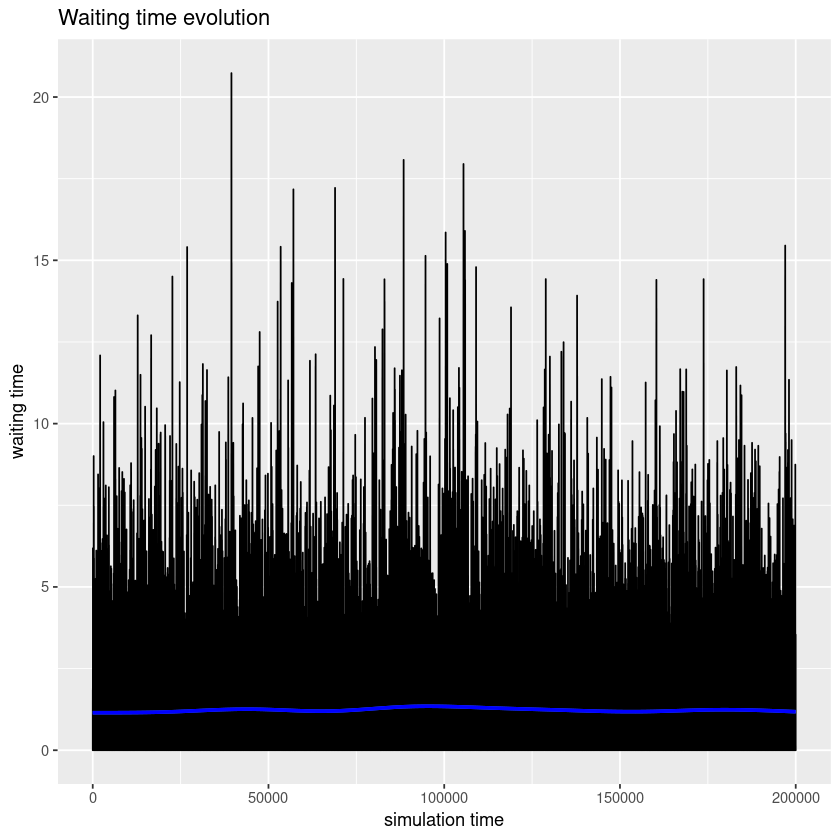

In [49]:
plot(res_arrivals, metric = "waiting_time") + geom_smooth (color= "blue")

Часто для повышения точности выполняют так называемый мультистарт или репликацию - в параллель запускается сразу несколько симуляций, из которых потом можно получить усреднение. 

Для этих целей можно использовать функцию lapply(X, FUN, ...) - она применяет функцию FUN к каждому элементу вектора x.

In [50]:
lapply(c(1,2,3),sin)

[[1]]
[1] 0.841471

[[2]]
[1] 0.9092974

[[3]]
[1] 0.14112

Удобнее такое выполнение распараллелить:

In [4]:
library(parallel)

mclapply(c(1,2,3),sin)

[[1]]
[1] 0.841471

[[2]]
[1] 0.9092974

[[3]]
[1] 0.14112

В нашем случае в качестве функции будет выступать каждая отдельная симуляция:

In [4]:
library(parallel)
res_sim <- mclapply(1:10, function(i) {
  simmer() %>%
  add_resource("server", capacity=1, queue_size=Inf) %>%
  add_generator("arrival", my.trajectory, function() rexp(1, lambda)) %>%
  run(until=Tmodel) %>%
  wrap()
})

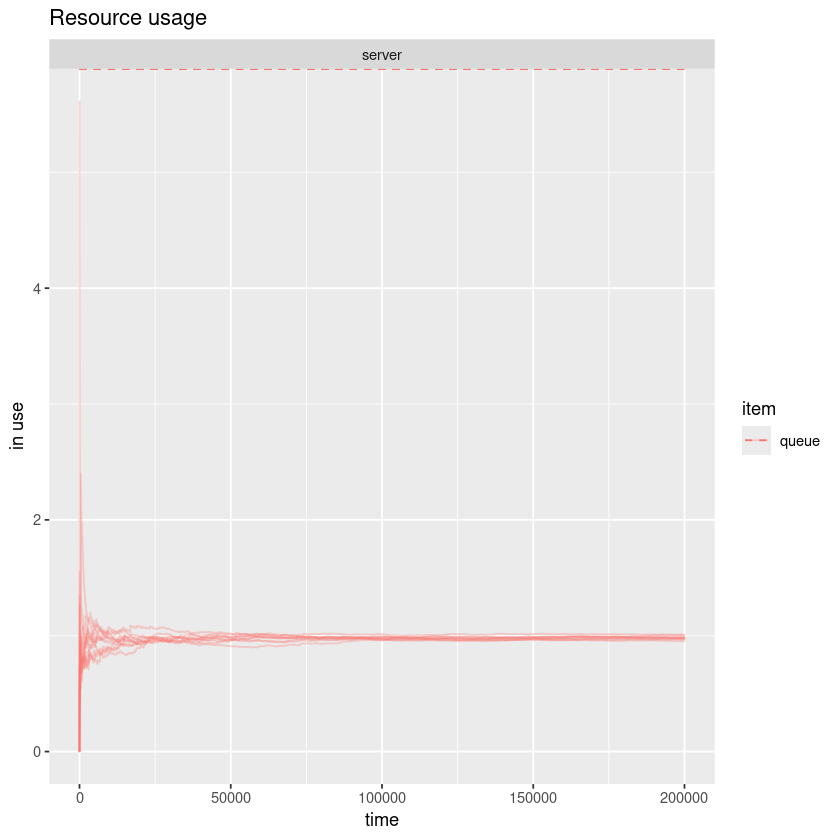

In [7]:
plot(get_mon_resources(res_sim), metric = "usage", items=c("queue"))

## Аппроксимация немарковских процессов

**Определение.** *Если промежутки времени между последовательными событиями представляют собой независимые, одинаково распределенные случайные величины $T_1, T_2, \ldots$, то такой поток событий называется *потоком Пальма**.

Простейший поток есть частный случай потока Пальма, где величины $T_i$ все распределены по показательному закону.

Важнейшими для практики образцами потоков Пальма являются потоки Эрланга. Эти потоки образуются в результате "просеивания" простейших потоков.

Например, если из простейшего взять только каждое второе событие, то новый поток образует поток Эрланга второго порядка,  $k$-ю точку - поток $k$-го порядка. 

В простейшем потоке вероятность, что за время $\tau$ придет ровно $k$ заявок равна
$$P_n=\frac{\left(\lambda \cdot \tau\right)^k}{k!}e^{-\lambda\cdot \tau}$$

Значит для потока Эрланга $k$-го порядка должно произойти $k-1$ событие простейшего потока, вероятность этого
$$\frac{\left(\lambda \cdot \tau\right)^{k-1}}{(k-1)!}e^{-\lambda\cdot \tau}$$

а также одно событие за интервал времени $dt$, вероятность этого $\lambda dt$.

Окончательно, плотность вероятности для потока Эрланга $k$-го порядка определится как:
$$f_k(t) = \frac{\lambda\left(\lambda \cdot t\right)^{k-1}}{(k-1)!}e^{-\lambda\cdot t}$$
$$M[t] = \frac{k}{\lambda}, D[t] = \frac{k}{\lambda^2}, \sigma[t] = \frac{\sqrt{k}}{\lambda}$$
где $\lambda$ - интенсивность простейшего потока, который подвергся прореживанию.

Закон Эрланга можно записать через свои характеристики: интенсивность потока Эрланга $k$-го порядка $\Lambda_k =\frac{\lambda}{k}$, т.е. берется $k$-я часть из $\lambda$. Тогда получаем:
$$f_k(t) = \frac{(k\Lambda_k)^k t^{k-1}}{(k-1)!}e^{-k\Lambda_k\cdot t}$$

$$M[t] = \frac{1}{\Lambda_k}, D[t] = \frac{1}{k\Lambda_k^2}$$

$$k=\frac{1}{D[t]\Lambda_k^2}=\frac{M^2[t]}{\sigma^2[t]}$$

Из последних формул видно, что при $k\rightarrow \infty$ получаем $D[t]\rightarrow 0$, т.е. поток Эрланга приближается к регулярному потоку с интервалом времени между событиями равным $\tau = \sum_{i=1}^k T_i$ - в этом случае имеем жесткую функциональную связь - последействие максимально, при $k=1$ - получаем отсутствие последействия.

Таким образом, порядок потока $k$ может служить в какой-то степени "мерой последействия". Реальный поток можно заменить потоком Эрланга, рассчитав порядок $k$ из величин дисперсии.

Рассмотрим пример.

**Пример 1.** Пусть получен поток с характеристиками $M[t] =1$ мин., $\sigma[t] = 0.5$ мин. Требуется подобрать подходящий поток Эрланга.

$$\Lambda_k = \frac{1}{M[t]} = \frac{1}{1}=1$$
$$k = \frac{M^2[t]}{\sigma^2[t]}\approx \frac{1^2}{0.5^2}\Rightarrow k = 4$$
Требуемый поток $f_4(t) = \frac{(4\cdot 1)^4}{3!}t^3\cdot e^{-4t}$

При помощи потоков Эрланга можно сводить немарковские процессы к марковским.

# Метод этапов

Сама по себе замена немарковского процесса потоком Эрланга соответствующего порядка не устраняет отсутствие последействия. Однако можно предположить, что мы имеем просеянный простейший поток, из которого этот поток Эрланга получился. Значит можно добавить требуемое количество фиктивных состояний простейшего потока, из которых нас будет интересовать каждое $k$-е состояние. Данная идея получила свое развитие в так называемом **методе этапов**.

Рассмотрим его использование на примере.

**Пример 2.** В одноканальную систему без очереди поступает простейший входной поток с интенсивностью $\lambda=0.2\text{мин}^{-1}$, однако поток обслуживания не является простейшим (промежутки времени, в течение которых заявки обслуживаются не распределены по показательному закону). Известно, что среднее время обслуживания $M[t] = \frac{1}{\mu} = 1 \text{мин.}$, среднее квадратическое отклонение интервалов обслуживания $\sigma[t] = 0.7 \text{мин.}$

По условию задачи мы имеем дело с системой $M/G/1/0$. 

<img src="1.jpeg">

$S_0$ - в системе нет заявок

$S_1$ - в системе одна заявка

Перейдем к рассмотрению квазиэквивалентной системы $M/E_k/1$ с потоком Эрланга $k$ порядка с сопоставимым уровнем последействия:

$k= \frac{M^2[t]}{\sigma^2[t]}=\frac{1^2}{0.7^2}\approx 2$

Будем считать, что обслуживание происходит в два этапа по показательному закону с интенсивностью $k\mu=2\mu=2\cdot 1 = 2$. Таким образом, вместо $S_1$ у нас добавляется $S_{11}, S_{12}$ 

<img src="2.jpeg">

$S_0$ - в системе нет заявок

$S_{11}$ - в системе одна заявка на первом этапе

$S_{12}$ - в системе одна заявка на втором этапе.

Для нахождения финальных вероятностей составим систему уравнений:

$$\begin{cases}
P_0\lambda = 2\mu P_{12}\\
P_{11}2\mu=P_0\lambda\\
P_{12}2\mu=P_{11}2\mu\Rightarrow P_{11}=P_{12}\\
P_{00}+P_{11}+P_{12}=1
\end{cases}$$


In [1]:
solve([P0*lambda = 2*mu*P12, P11*2*mu=P0*lambda, P0+P11+P12=1],[P0,P11,P12]);

                 mu                 lambda                 lambda
(%o0) [[P0 = -----------, P11 = ---------------, P12 = ---------------]]
             lambda + mu        2 lambda + 2 mu        2 lambda + 2 mu

Таким образом, получаем $$P_0 = \frac{\mu}{\lambda+\mu}, P_{11}=P_{12}=\frac{\lambda}{2(\lambda+\mu)}$$

In [1]:
lambda:0.2$ mu:1$
solve([P0*lambda = 2*mu*P12, P11*2*mu=P0*lambda, P0+P11+P12=1],[P0,P11,P12]);


rat: replaced 0.2 by 1/5 = 0.2

rat: replaced -0.2 by -1/5 = -0.2


                               5        1         1
(%o2)                   [[P0 = -, P11 = --, P12 = --]]
                               6        12        12

In [2]:
float(%);

(%o3) [[P0 = 0.8333333333333334, P11 = 0.08333333333333333, 
                                                    P12 = 0.08333333333333333]]

Рассмотрим основные показатели эффективности этой системы:
- абсолютная пропускная способность:
$$\lambda'=P0\cdot \lambda\approx 0.166$$
- Вероятность отказа:
$$P_{11}+P_{12}\approx 0.166$$
- Среднее число заявок в системе:
$$L_{\text{сист}}=1\cdot P_{11}+1\cdot P_{12}\approx 0.166$$
- Среднее время нахождения завки в системе:
$$W_{\text{сист}}=\frac{L_{\text{сист}}}{\lambda}\approx 0.83$$

In [2]:
#Подключаем данные библиотеки
library(simmer)
library(simmer.plot)

Загрузка требуемого пакета: ggplot2


Присоединяю пакет: ‘simmer.plot’


Следующие объекты скрыты от ‘package:simmer’:

    get_mon_arrivals, get_mon_attributes, get_mon_resources




In [9]:
1/mean(rgamma(100000, k, 2*mu))

[1] 1.000057

Tsys = 0.8318329

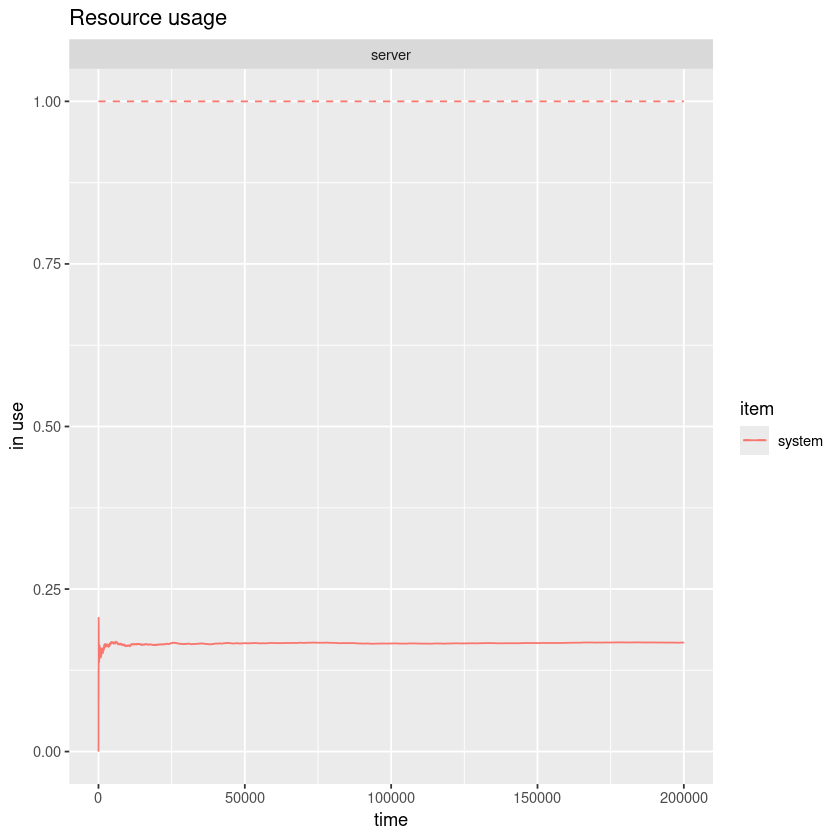

In [5]:
#Создание траектории системы M/E_2/1
lambda <- 0.2
mu <- 1
k <- 2

my.trajectory <- trajectory() %>%
  seize("server", amount=1) %>%
  timeout(function() rgamma(1, k, 2*mu)) %>%
  release("server", amount=1)
          
Tmodel<-200000
me2_1_0 <- simmer() %>%
  add_resource("server", capacity=1, queue_size=0) %>%
  add_generator("arrival", my.trajectory, function() rexp(1, lambda)) %>%
  run(until=Tmodel)
                
res_arrivals <- get_mon_arrivals(me2_1_0)
res_resource<-get_mon_resources(me2_1_0)
cat("Tsys =", mean(res_arrivals$end_time - res_arrivals$start_time))
                
# Среднее число заявок в системе
plot(get_mon_resources(me2_1_0), "usage", "server", items="system")

Tsys = 0.8314757

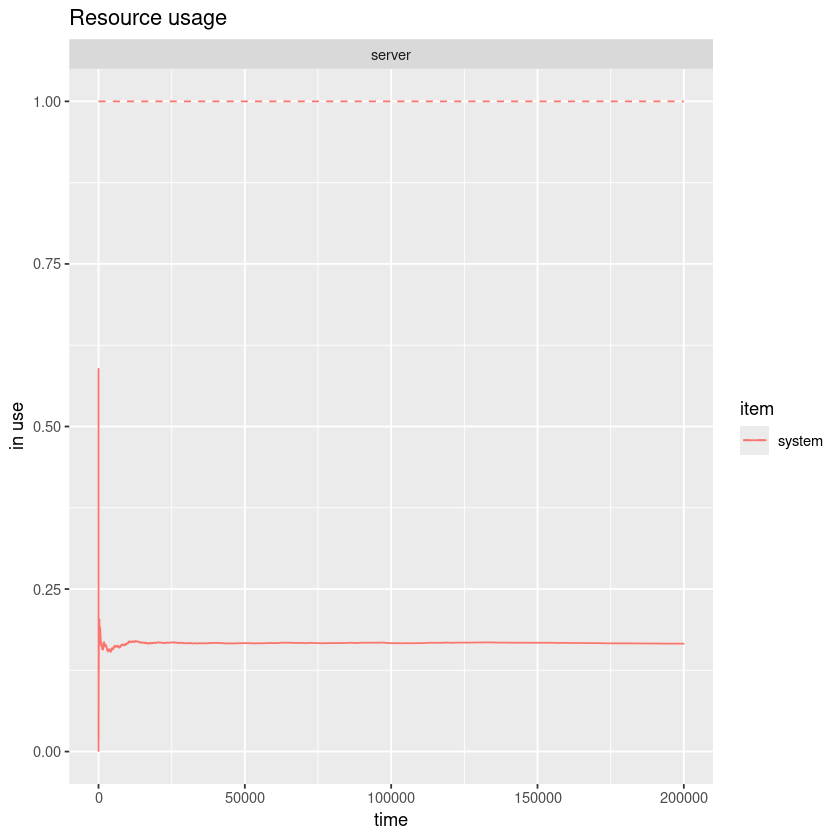

In [11]:
#M/MM/1/0

lambda <- 0.2
mu <- 1


my.trajectory <- trajectory() %>%
  seize("server", amount=1) %>%
  timeout(function() rexp(1, 2*mu)) %>%
  release("server", amount=1) %>%
  seize("server", amount=1) %>%
  timeout(function() rexp(1, 2*mu)) %>%
  release("server", amount=1)
          
Tmodel<-200000
mmm_1_0 <- simmer() %>%
  add_resource("server", capacity=1, queue_size=0) %>%
  add_generator("arrival", my.trajectory, function() rexp(1, lambda)) %>%
  run(until=Tmodel)
                
res_arrivals <- get_mon_arrivals(mmm_1_0)
res_resource<-get_mon_resources(mmm_1_0)
cat("Tsys =", mean(res_arrivals$end_time - res_arrivals$start_time))
# Среднее число заявок в системе
plot(get_mon_resources(mm_1_0), "usage", "server", items="system")

**Пример 3.** В одноканальную систему с ограничением на длину очереди в 2 места поступает простейший входной поток с интенсивностью $\lambda=0.2\text{мин}^{-1}$, однако поток обслуживания не является простейшим (промежутки времени, в течение которых заявки обслуживаются не распределены по показательному закону). Известно, что среднее время обслуживания $M[t] = \frac{1}{\mu} = 1 \text{мин.}$, среднее квадратическое отклонение интервалов обслуживания $\sigma[t] = 0.577 \text{мин.}$

По условию задачи мы имеем дело с системой $M/G/1/3$.

Проведем эквивалентирование потоками Эрланга $M/E_k/1/3$

$$k=\frac{M^2[t]}{\sigma^2[t]}=\frac{1^2}{0.577^2}\approx 3$$

Используем метод этапов:

<img src="3.jpeg">

Составим систему уравнений

$$\begin{cases}
P_0\lambda=3\mu P_{13}\\
(\lambda+3\mu)P_{11}=\lambda P_0+3\mu P_{23}\\
(\lambda+3\mu)P_{12}=\lambda P_{11}+3\mu P_{33}\\
3\mu P_{31}=\lambda P_{21}\\
(\lambda+3\mu)P_{12}=3\mu P_{11}\\
(\lambda+3\mu)P_{22}=\lambda P_{12}+3\mu P_{21}\\
3\mu P_{32}=\lambda P_{22}+3\mu P_{31}\\
(\lambda+3\mu)P_{13}=3\mu P_{12}\\
(\lambda+3\mu) P_{23}=3\mu P_{22}+\lambda P_{13}\\
\end{cases}$$

In [2]:
lambda:0.2$ mu:1$

solve([lambda*P0=3*mu*P13,
       (lambda+3*mu)*P11=lambda*P0+3*mu*P23,
       (lambda+3*mu)*P12=lambda*P11+3*mu*P33,
       3*mu*P31=lambda*P21,
       (lambda+3*mu)*P12=3*mu*P11,
       (lambda+3*mu)*P22=lambda*P12+3*mu*P21,
       3*mu*P32=lambda*P22+3*mu*P31,
       (lambda+3*mu)*P13=3*mu*P12,
       (lambda+3*mu)*P23=3*mu*P22+lambda*P13,
       P0+P11+P21+P31+P12+P22+P32+P13+P23+P33=1],
      [P0,P11,P21,P31,P12,P22,P32,P13,P23,P33]);


rat: replaced 0.2 by 1/5 = 0.2

rat: replaced -0.2 by -1/5 = -0.2

rat: replaced 3.2 by 16/5 = 3.2

rat: replaced -0.2 by -1/5 = -0.2

rat: replaced 3.2 by 16/5 = 3.2

rat: replaced -0.2 by -1/5 = -0.2

rat: replaced 3.2 by 16/5 = 3.2

rat: replaced -0.2 by -1/5 = -0.2

rat: replaced 3.2 by 16/5 = 3.2

rat: replaced -0.2 by -1/5 = -0.2

rat: replaced 3.2 by 16/5 = 3.2

rat: replaced -0.2 by -1/5 = -0.2

rat: replaced 3.2 by 16/5 = 3.2


             170859375        12960000          1148640           76576
(%o5) [[P0 = ---------, P11 = ---------, P21 = ---------, P31 = ---------, 
             225149807        225149807        225149807        225149807
      12150000          1836225          198991          11390625
P12 = ---------, P22 = ---------, P32 = ---------, P13 = ---------, 
      225149807        225149807        225149807        225149807
       2433375         12096000
P23 = ---------, P33 = ---------]]
      225149807        225149807

In [3]:
float(%);

(%o6) [[P0 = 0.7588697377830752, P11 = 0.05756167492517549, 
P21 = 0.005101669929479442, P31 = 3.401113286319629e-4, 
P12 = 0.05396407024235202, P22 = 0.008155569949033978, 
P32 = 8.838159919008947e-4, P13 = 0.05059131585220502, 
P23 = 0.01080780406798217, P33 = 0.05372422993016378]]

- Среднее число заявок в системе:
$$L_{\text{сист}}=1\cdot (P_{11}+P_{12}+P_{13})+2\cdot (P_{21}+P_{22}+P_{23})+3\cdot(P_{31}+P_{32}+P_{33})\approx 0.37$$
- Среднее время нахождения завки в системе:
$$W_{\text{сист}}=\frac{L_{\text{сист}}}{\lambda}\approx 1.875$$

Tsys = 1.850462

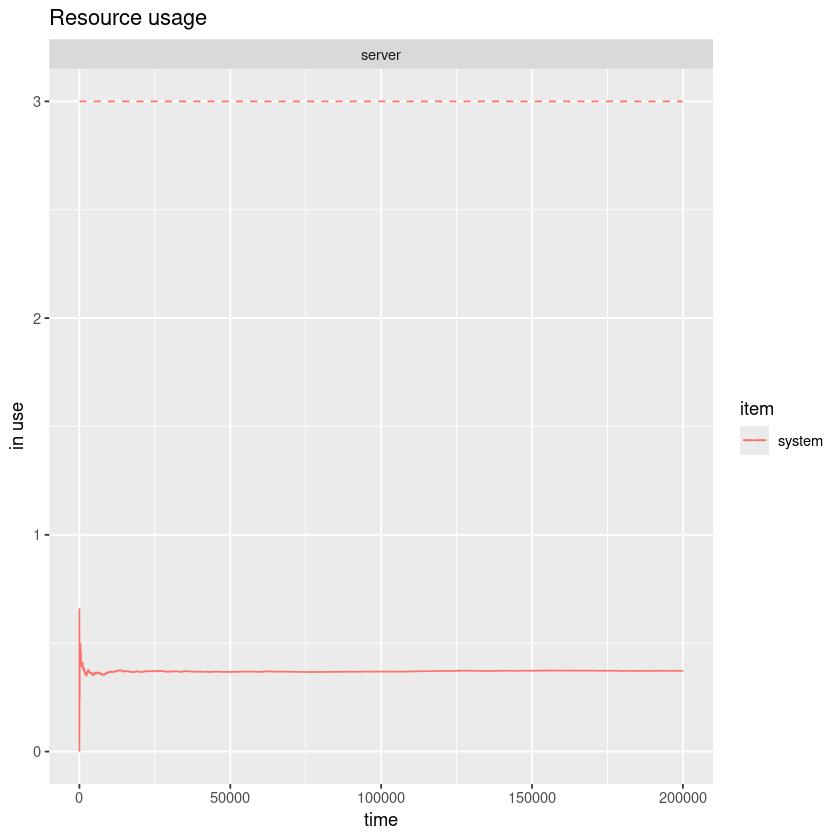

In [26]:
#Создание траектории системы M/E_3/1/2
lambda <- 0.2
mu <- 1
k <- 3

my.trajectory <- trajectory() %>%
  seize("server", amount=1) %>%
  timeout(function() rgamma(1, k, 2*mu)) %>%
  release("server", amount=1)
          
Tmodel<-200000
me3_1_2 <- simmer() %>%
  add_resource("server", capacity=1, queue_size=2) %>%
  add_generator("arrival", my.trajectory, function() rexp(1, lambda)) %>%
  run(until=Tmodel)
                
res_arrivals <- get_mon_arrivals(me3_1_2)
res_resource<-get_mon_resources(me3_1_2)
cat("Tsys =", mean(res_arrivals$end_time - res_arrivals$start_time))
                
# Среднее число заявок в системе
plot(get_mon_resources(me3_1_2), "usage", "server", items="system")